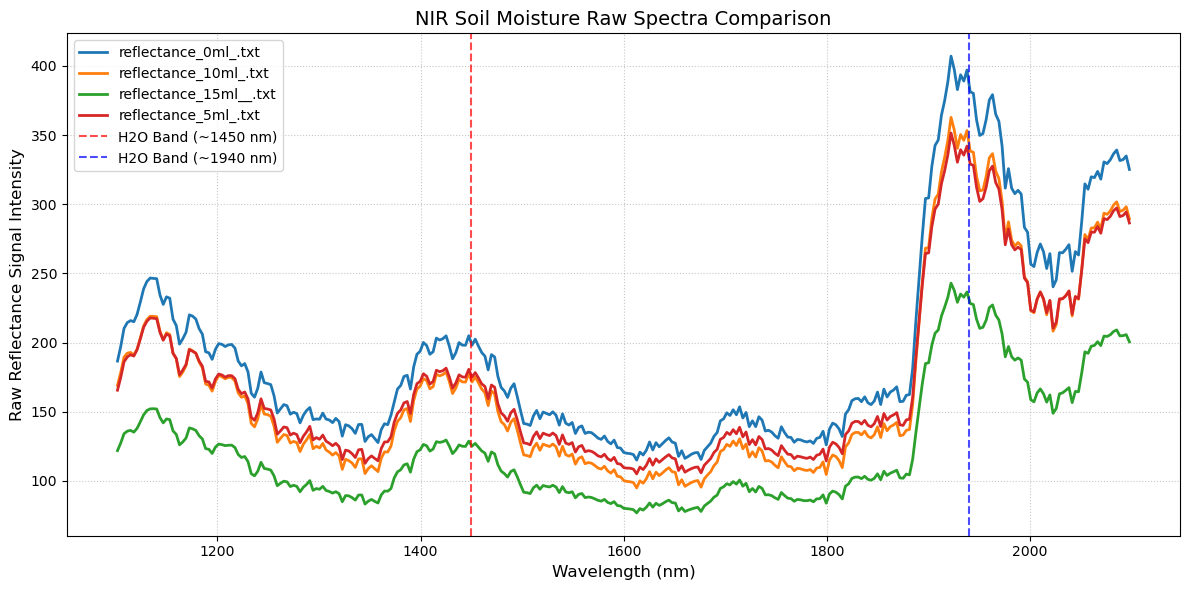

In [8]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

folder_path = '.'


def load_oceanview_txt(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    data_start = 0
    for i, line in enumerate(lines):
        if '>>>>>Begin Spectral Data<<<<<' in line:
            data_start = i + 1
            break

    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        sep=r'\s+',
        header=None,
        engine='python',
    )
    df = df.iloc[:, :2]
    df.columns = ['Wavelength', 'Reflectance']

    df['Wavelength'] = pd.to_numeric(df['Wavelength'], errors='coerce')
    df['Reflectance'] = pd.to_numeric(df['Reflectance'], errors='coerce')

    df = df.dropna().reset_index(drop=True)
    df = df[np.isfinite(df['Reflectance'])]

    # Focus strictly on valid NIR zone
    df = df[(df['Wavelength'] >= 1100) & (df['Wavelength'] <= 2100)]
    return df


search_pattern = os.path.join(folder_path, '*.txt')
all_files = sorted(glob.glob(search_pattern))

if not all_files:
    print(f"No .txt files found in '{folder_path}'.")
else:
    plt.figure(figsize=(12, 6))

    for filepath in all_files:
        filename = os.path.basename(filepath)
        df = load_oceanview_txt(filepath)

        if len(df) < 25:
            continue

        # Smooth signal without changing its physical scale
        smoothed = savgol_filter(
            df['Reflectance'], window_length=25, polyorder=2, mode='nearest'
        )

        plt.plot(df['Wavelength'], smoothed, label=filename, linewidth=2)

    # Reference Bands
    plt.axvline(
        x=1450,
        color='red',
        linestyle='--',
        alpha=0.7,
        label='H2O Band (~1450 nm)',
    )
    plt.axvline(
        x=1940,
        color='blue',
        linestyle='--',
        alpha=0.7,
        label='H2O Band (~1940 nm)',
    )

    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Raw Reflectance Signal Intensity', fontsize=12)
    plt.title('NIR Soil Moisture Raw Spectra Comparison', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

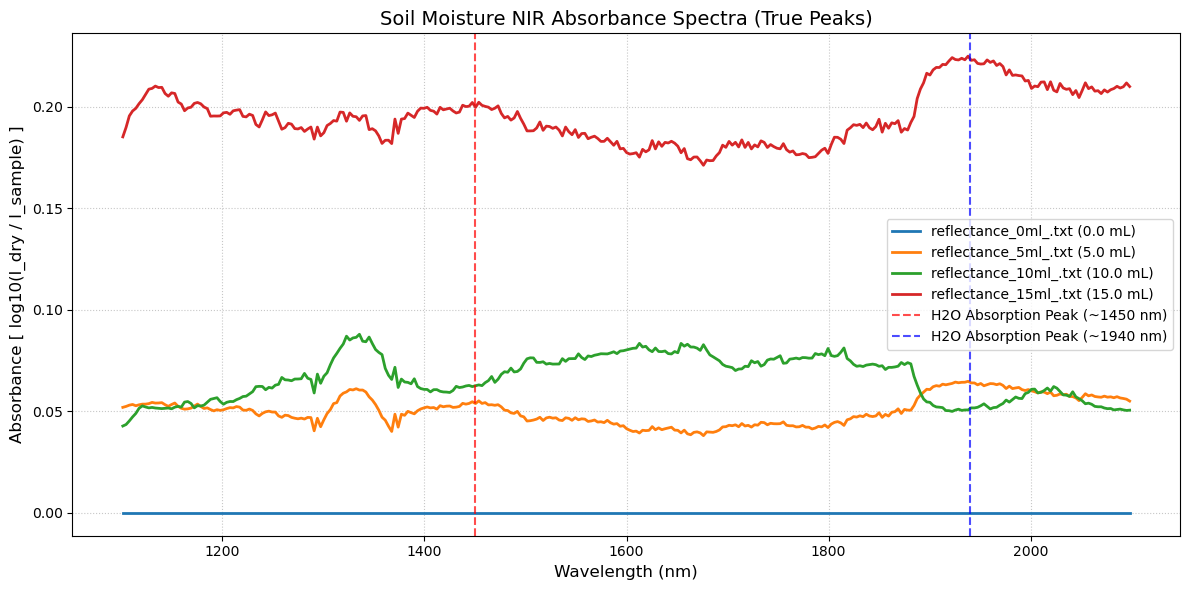

In [13]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. SETUP PATH AND FILE MAPPING
folder_path = '.'  # Update with your folder path

moisture_labels = {
    'reflectance_0ml_.txt': 0.0,
    'reflectance_5ml_.txt': 5.0,
    'reflectance_10ml_.txt': 10.0,
    'reflectance_15ml_.txt': 15.0,
}


# 2. FILE PARSER & PREPROCESSING
def load_oceanview_txt(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    data_start = 0
    for i, line in enumerate(lines):
        if '>>>>>Begin Spectral Data<<<<<' in line:
            data_start = i + 1
            break

    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        sep=r'\s+',
        header=None,
        engine='python',
    )
    df = df.iloc[:, :2]
    df.columns = ['Wavelength', 'Reflectance']

    df['Wavelength'] = pd.to_numeric(df['Wavelength'], errors='coerce')
    df['Reflectance'] = pd.to_numeric(df['Reflectance'], errors='coerce')

    df = df.dropna().reset_index(drop=True)
    df = df[np.isfinite(df['Reflectance'])]

    # Focus on clean optical zone (1100 - 2100 nm)
    df = df[(df['Wavelength'] >= 1100) & (df['Wavelength'] <= 2100)]
    return df

# 3. RELATIVE ABSORBANCE TRANSFORM (A = log10( I_dry / I_sample ))
# First pass: Load dry reference spectrum (0 mL)
dry_filepath = os.path.join(folder_path, 'reflectance_0ml_.txt')
df_dry = load_oceanview_txt(dry_filepath)
I_dry = savgol_filter(
    df_dry['Reflectance'], window_length=25, polyorder=2, mode='nearest'
)

X_list = []
y_list = []

plt.figure(figsize=(12, 6))

for filename, moisture in moisture_labels.items():
    filepath = os.path.join(folder_path, filename)

    if os.path.exists(filepath):
        df = load_oceanview_txt(filepath)

        # Smooth raw intensity signal
        I_sample = savgol_filter(
            df['Reflectance'], window_length=25, polyorder=2, mode='nearest'
        )

        # True Absorbance relative to dry soil baseline
        absorbance = np.log10(I_dry / np.clip(I_sample, 1e-5, None))

        plt.plot(
            df['Wavelength'],
            absorbance,
            label=f'{filename} ({moisture} mL)',
            linewidth=2,
        )

        X_list.append(absorbance)
        y_list.append(moisture)

# Plot Formatting
plt.axvline(
    x=1450,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='H2O Absorption Peak (~1450 nm)',
)
plt.axvline(
    x=1940,
    color='blue',
    linestyle='--',
    alpha=0.7,
    label='H2O Absorption Peak (~1940 nm)',
)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Absorbance [ log10(I_dry / I_sample) ]', fontsize=12)
plt.title('Soil Moisture NIR Absorbance Spectra (True Peaks)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

             PLSR MODEL EVALUATION              
Sample 1 ( 0.0 mL) | Fitted:  1.79 mL | Cross-Val:  3.92 mL
Sample 2 ( 5.0 mL) | Fitted:  5.45 mL | Cross-Val:  5.63 mL
Sample 3 (10.0 mL) | Fitted:  6.74 mL | Cross-Val:  5.57 mL
Sample 4 (15.0 mL) | Fitted: 16.02 mL | Cross-Val: 26.61 mL
--------------------------------------------------
Training R² : 0.8794  |  Training RMSE : 1.941 mL
Cross-Val R²: -0.3608  |  Cross-Val RMSE: 6.521 mL


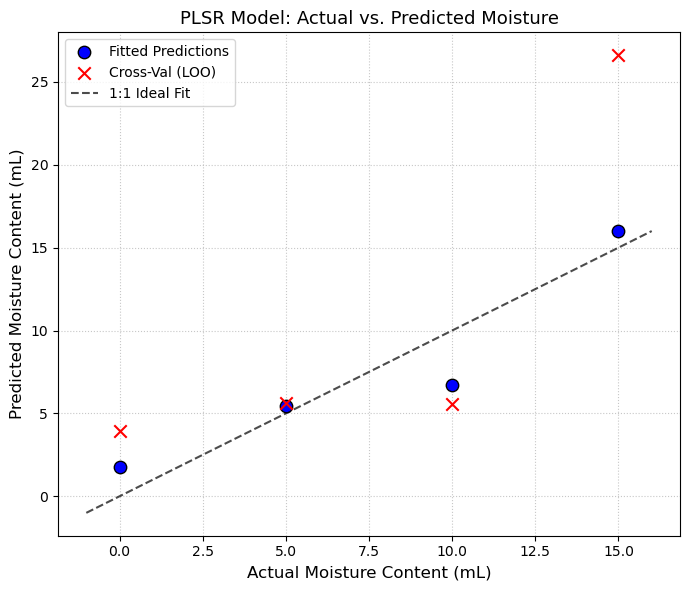

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

# Convert feature and target lists to NumPy matrices
X = np.array(X_list)  # Absorbance matrix
y = np.array(y_list)  # Target moisture values (mL)

# Initialize 2-Component PLS Regression
pls = PLSRegression(n_components=1)
pls.fit(X, y)

# Predict on full dataset
y_pred = pls.predict(X).ravel()

# Cross-Validation (Leave-One-Out)
loo = LeaveOneOut()
y_cv_pred = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = PLSRegression(n_components=1)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    # Flatten array safely to extract single scalar prediction
    y_cv_pred.append(pred.ravel()[0])

y_cv_pred = np.array(y_cv_pred)

# Metrics Calculation
r2_fit = r2_score(y, y_pred)
rmse_fit = np.sqrt(mean_squared_error(y, y_pred))

r2_cv = r2_score(y, y_cv_pred)
rmse_cv = np.sqrt(mean_squared_error(y, y_cv_pred))

# Print Results
print('=' * 50)
print('             PLSR MODEL EVALUATION              ')
print('=' * 50)
for i in range(len(y)):
    print(
        f'Sample {i+1} ({y[i]:4.1f} mL) | Fitted: {y_pred[i]:5.2f} mL | Cross-Val: {y_cv_pred[i]:5.2f} mL'
    )

print('-' * 50)
print(f'Training R² : {r2_fit:.4f}  |  Training RMSE : {rmse_fit:.3f} mL')
print(f'Cross-Val R²: {r2_cv:.4f}  |  Cross-Val RMSE: {rmse_cv:.3f} mL')
print('=' * 50)

# Scatter Plot: Actual vs. Predicted
plt.figure(figsize=(7, 6))
plt.scatter(
    y,
    y_pred,
    color='blue',
    s=80,
    edgecolor='k',
    zorder=3,
    label='Fitted Predictions',
)
plt.scatter(
    y,
    y_cv_pred,
    color='red',
    marker='x',
    s=80,
    zorder=4,
    label='Cross-Val (LOO)',
)
plt.plot(
    [min(y) - 1, max(y) + 1],
    [min(y) - 1, max(y) + 1],
    'k--',
    alpha=0.7,
    label='1:1 Ideal Fit',
)

plt.xlabel('Actual Moisture Content (mL)', fontsize=12)
plt.ylabel('Predicted Moisture Content (mL)', fontsize=12)
plt.title('PLSR Model: Actual vs. Predicted Moisture', fontsize=13)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

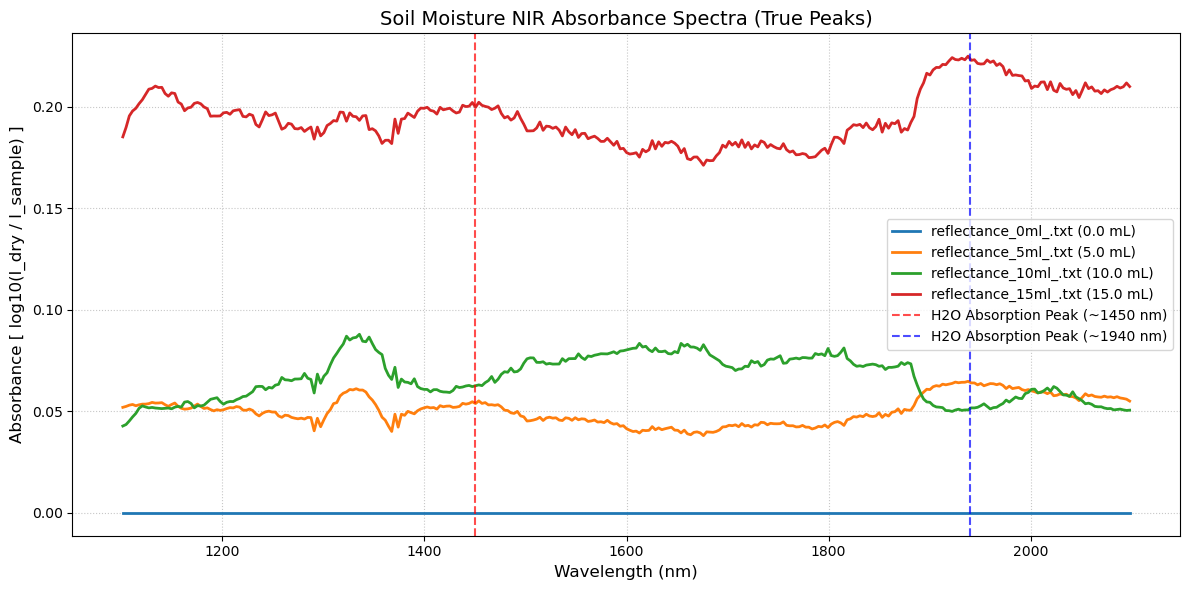

             PLSR MODEL EVALUATION              
Sample 1 ( 0.0 mL) | Fitted:  1.79 mL | Cross-Val:  3.92 mL
Sample 2 ( 5.0 mL) | Fitted:  5.45 mL | Cross-Val:  5.63 mL
Sample 3 (10.0 mL) | Fitted:  6.74 mL | Cross-Val:  5.57 mL
Sample 4 (15.0 mL) | Fitted: 16.02 mL | Cross-Val: 26.61 mL
--------------------------------------------------
Training R² : 0.8794  |  Training RMSE : 1.941 mL
Cross-Val R²: -0.3608  |  Cross-Val RMSE: 6.521 mL


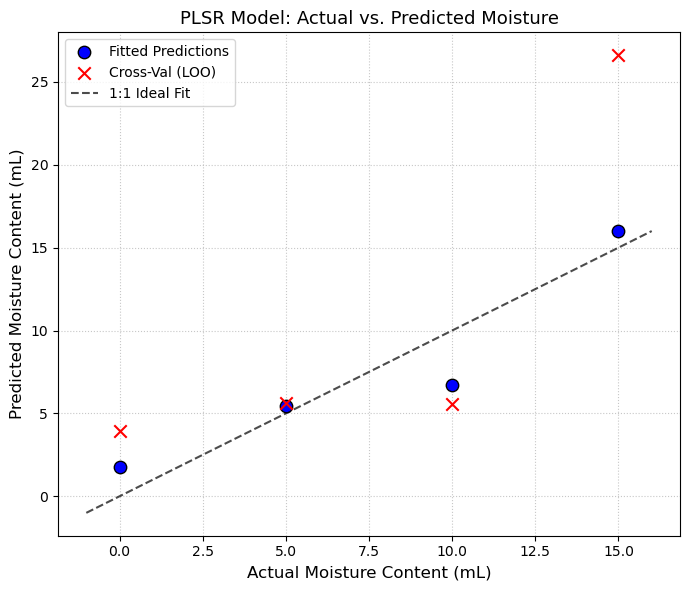

In [18]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

# 1. SETUP PATH AND FILE MAPPING
folder_path = "."  # Standardized quotes and spaces

moisture_labels = {
    "reflectance_0ml_.txt": 0.0,
    "reflectance_5ml_.txt": 5.0,
    "reflectance_10ml_.txt": 10.0,
    "reflectance_15ml_.txt": 15.0,
}


# 2. FILE PARSER & PREPROCESSING

def load_oceanview_txt(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    data_start = 0
    for i, line in enumerate(lines):
        if ">>>>>Begin Spectral Data<<<<<" in line:
            data_start = i + 1
            break

    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        sep=r"\s+",
        header=None,
        engine="python",
    )
    df = df.iloc[:, :2]
    df.columns = ["Wavelength", "Reflectance"]

    df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")
    df["Reflectance"] = pd.to_numeric(df["Reflectance"], errors="coerce")

    df = df.dropna().reset_index(drop=True)
    df = df[np.isfinite(df["Reflectance"])]

    # Clean optical zone (1100 - 2100 nm)
    df = df[(df["Wavelength"] >= 1100) & (df["Wavelength"] <= 2100)]
    return df


# 3. RELATIVE ABSORBANCE TRANSFORM (A = log10( I_dry / I_sample ))
# First pass: Load dry reference spectrum (0 mL) baseline
dry_filepath = os.path.join(folder_path, "reflectance_0ml_.txt")
df_dry = load_oceanview_txt(dry_filepath)
I_dry = savgol_filter(
    df_dry["Reflectance"], window_length=25, polyorder=2, mode="nearest"
)

X_list = []
y_list = []

plt.figure(figsize=(12, 6))

for filename, moisture in moisture_labels.items():
    filepath = os.path.join(folder_path, filename)

    if os.path.exists(filepath):
        df = load_oceanview_txt(filepath)

        # Smooth raw intensity signal
        I_sample = savgol_filter(
            df["Reflectance"], window_length=25, polyorder=2, mode="nearest"
        )

        # True Absorbance relative to dry baseline
        absorbance = np.log10(I_dry / np.clip(I_sample, 1e-5, None))

        plt.plot(
            df["Wavelength"],
            absorbance,
            label=f"{filename} ({moisture} mL)",
            linewidth=2,
        )

        X_list.append(absorbance)
        y_list.append(moisture)

# Plot Formatting
plt.axvline(
    x=1450,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="H2O Absorption Peak (~1450 nm)",
)
plt.axvline(
    x=1940,
    color="blue",
    linestyle="--",
    alpha=0.7,
    label="H2O Absorption Peak (~1940 nm)",
)
plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Absorbance [ log10(I_dry / I_sample) ]", fontsize=12)
plt.title("Soil Moisture NIR Absorbance Spectra (True Peaks)", fontsize=14)
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()


# 4. PLSR MODEL TRAINING AND LEAVE-ONE-OUT CROSS-VALIDATION
X = np.array(X_list)  # Absorbance matrix
y = np.array(y_list)  # Target moisture values (mL)

# Initialize 1-Component PLS Regression
pls = PLSRegression(n_components=1)
pls.fit(X, y)

# Predict on full dataset
y_pred = pls.predict(X).ravel()

# Cross-Validation (Leave-One-Out)
loo = LeaveOneOut()
y_cv_pred = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = PLSRegression(n_components=1)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    y_cv_pred.append(pred.ravel()[0])

y_cv_pred = np.array(y_cv_pred)

# Metrics Calculation
r2_fit = r2_score(y, y_pred)
rmse_fit = np.sqrt(mean_squared_error(y, y_pred))

r2_cv = r2_score(y, y_cv_pred)
rmse_cv = np.sqrt(mean_squared_error(y, y_cv_pred))

# Print Results
print("=" * 50)
print("             PLSR MODEL EVALUATION              ")
print("=" * 50)
for i in range(len(y)):
    print(
        f"Sample {i+1} ({y[i]:4.1f} mL) | Fitted: {y_pred[i]:5.2f} mL | Cross-Val: {y_cv_pred[i]:5.2f} mL"
    )

print("-" * 50)
print(f"Training R² : {r2_fit:.4f}  |  Training RMSE : {rmse_fit:.3f} mL")
print(f"Cross-Val R²: {r2_cv:.4f}  |  Cross-Val RMSE: {rmse_cv:.3f} mL")
print("=" * 50)

# Scatter Plot: Actual vs. Predicted
plt.figure(figsize=(7, 6))
plt.scatter(
    y,
    y_pred,
    color="blue",
    s=80,
    edgecolor="k",
    zorder=3,
    label="Fitted Predictions",
)
plt.scatter(
    y,
    y_cv_pred,
    color="red",
    marker="x",
    s=80,
    zorder=4,
    label="Cross-Val (LOO)",
)
plt.plot(
    [min(y) - 1, max(y) + 1],
    [min(y) - 1, max(y) + 1],
    "k--",
    alpha=0.7,
    label="1:1 Ideal Fit",
)

plt.xlabel("Actual Moisture Content (mL)", fontsize=12)
plt.ylabel("Predicted Moisture Content (mL)", fontsize=12)
plt.title("PLSR Model: Actual vs. Predicted Moisture", fontsize=13)
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()